In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

In [4]:
# Load dataset
data_path = r"C:\Users\MSI1\Downloads\People Analytic\People Analytic - Data train.csv"
df = pd.read_csv(data_path)

print("Shape awal:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\MSI1\\Downloads\\People Analytic\\People Analytic - Data train.csv'

In [ ]:
# Quick audit
print("Info dataset:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

print("\nMissing values per column:")
missing = pd.DataFrame({
    "missing_value": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)
display(missing[missing["missing_value"] > 0])

print("\nDuplicate rows:", df.duplicated().sum())

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
me

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,NaN,NaN,NaN,16875.358179,9616.292592,1.0,8554.25,16982.5,25169.75,33380.0
city,19158,123,city_103,4355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_development_index,19158.0,NaN,NaN,NaN,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
gender,14650,3,Male,13221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relevent_experience,19158,2,Has relevent experience,13792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrolled_university,18772,3,no_enrollment,13817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,18698,5,Graduate,11598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_discipline,16345,6,STEM,14492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,19093,22,>20,3286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,13220,8,50-99,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values per column:


,missing_value,missing_pct
company_type,6140,32.05
company_size,5938,30.99
gender,4508,23.53
major_discipline,2813,14.68
education_level,460,2.40
last_new_job,423,2.21
enrolled_university,386,2.01
experience,65,0.34



Duplicate rows: 0


## Data Cleaning

In [ ]:
# Rapikan nama kolom
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={"relevent_experience": "relevant_experience"})

# Hilangkan duplikat
df = df.drop_duplicates().reset_index(drop=True)

# Rapikan nilai string
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Kembalikan string "nan" ke NaN
df = df.replace("nan", np.nan)

print("Shape setelah drop duplicates:", df.shape)

Shape setelah drop duplicates: (19158, 14)


C:\Users\MSI1\AppData\Local\Temp\ipykernel_24616\3772387749.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [ ]:
# Missing value handling untuk kolom kategorikal
# Dalam People Analytics, nilai kosong sering lebih baik disimpan sebagai "Unknown"
categorical_fill_cols = [
    "gender",
    "relevant_experience",
    "enrolled_university",
    "education_level",
    "major_discipline",
    "company_type",
    "city",
]

for col in categorical_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# company_size tetap diisi Unknown dulu, lalu akan dibuat versi ordinal numerik
df["company_size"] = df["company_size"].fillna("Unknown")

# experience dan last_new_job dibiarkan dulu untuk diubah ke ordinal numeric
print(df.isna().sum().sort_values(ascending=False).head(10))

last_new_job              423
experience                 65
enrollee_id                 0
city                        0
city_development_index      0
gender                      0
relevant_experience         0
enrolled_university         0
education_level             0
major_discipline            0
dtype: int64


In [ ]:
# Konversi target menjadi integer
df["target"] = pd.to_numeric(df["target"], errors="coerce").astype("Int64")
df["target_label"] = df["target"].map({0: "Stay", 1: "Job Change"})

In [ ]:
# Ubah experience ke ordinal numeric
experience_map = {"<1": 0, ">20": 21}
df["experience_num"] = df["experience"].replace(experience_map)
df["experience_num"] = pd.to_numeric(df["experience_num"], errors="coerce")
df["experience_num"] = df["experience_num"].fillna(df["experience_num"].median()).astype(int)

# Ubah last_new_job ke ordinal numeric
last_job_map = {"never": 0, ">4": 5}
df["last_new_job_num"] = df["last_new_job"].replace(last_job_map)
df["last_new_job_num"] = pd.to_numeric(df["last_new_job_num"], errors="coerce")
df["last_new_job_num"] = df["last_new_job_num"].fillna(df["last_new_job_num"].median()).astype(int)

# Ubah company_size ke ordinal numeric
company_size_map = {
    "<10": 1,
    "10/49": 2,
    "50-99": 3,
    "100-500": 4,
    "500-999": 5,
    "1000-4999": 6,
    "5000-9999": 7,
    "10000+": 8
}
df["company_size_num"] = df["company_size"].map(company_size_map)
df["company_size_num"] = df["company_size_num"].fillna(df["company_size_num"].median()).astype(int)

# Pastikan city_development_index dan training_hours bertipe numerik
df["city_development_index"] = pd.to_numeric(df["city_development_index"], errors="coerce")
df["training_hours"] = pd.to_numeric(df["training_hours"], errors="coerce")

In [ ]:
df.dtypes

enrollee_id                 int64
city                          str
city_development_index    float64
gender                        str
relevant_experience           str
enrolled_university           str
education_level               str
major_discipline              str
experience                    str
company_size                  str
company_type                  str
last_new_job                  str
training_hours              int64
target                      Int64
target_label                  str
experience_num              int64
last_new_job_num            int64
company_size_num            int64
dtype: object

## Outlier Check

In [ ]:
numeric_cols = ["city_development_index", "training_hours", "experience_num", "last_new_job_num", "company_size_num"]

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

outlier_summary = []
for col in numeric_cols:
    count, lower, upper = iqr_outlier_count(df[col].dropna())
    outlier_summary.append({"column": col, "outlier_count": count, "lower_bound": lower, "upper_bound": upper})

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

,column,outlier_count,lower_bound,upper_bound
0,city_development_index,17,0.47,1.19
1,training_hours,984,-74.50,185.50
2,experience_num,0,-14.00,34.00
3,last_new_job_num,0,-2.00,6.00
4,company_size_num,5218,1.50,5.50


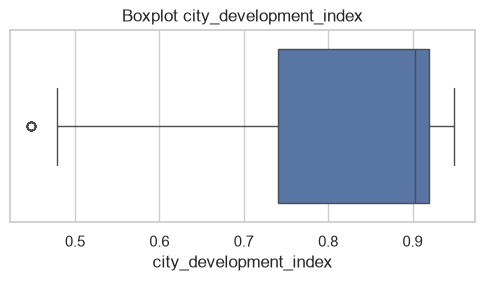

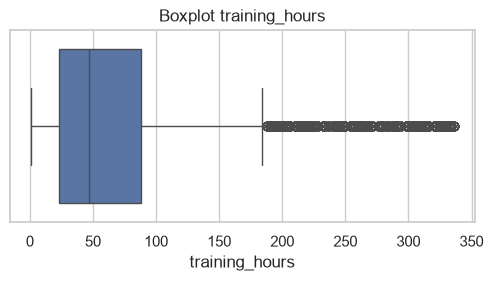

In [ ]:
# Boxplot sederhana
for col in ["city_development_index", "training_hours"]:
    plt.figure(figsize=(6, 2.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

## Normality Check

Untuk dataset besar seperti ini, uji normalitas formal sering sangat sensitif. Karena itu, cek distribusi sebaiknya dilihat dengan histogram, QQ plot, skewness, dan kurtosis.

In [ ]:
norm_cols = ["city_development_index", "training_hours", "experience_num", "last_new_job_num", "company_size_num"]

normality_summary = []
for col in norm_cols:
    s = df[col].dropna()
    normality_summary.append({
        "column": col,
        "skewness": s.skew(),
        "kurtosis": s.kurt()
    })

normality_summary_df = pd.DataFrame(normality_summary)
display(normality_summary_df)

,column,skewness,kurtosis
0,city_development_index,-0.995428,-0.538532
1,training_hours,1.819237,3.840539
2,experience_num,0.411316,-1.165186
3,last_new_job_num,0.833015,-0.696440
4,company_size_num,0.621744,0.091303


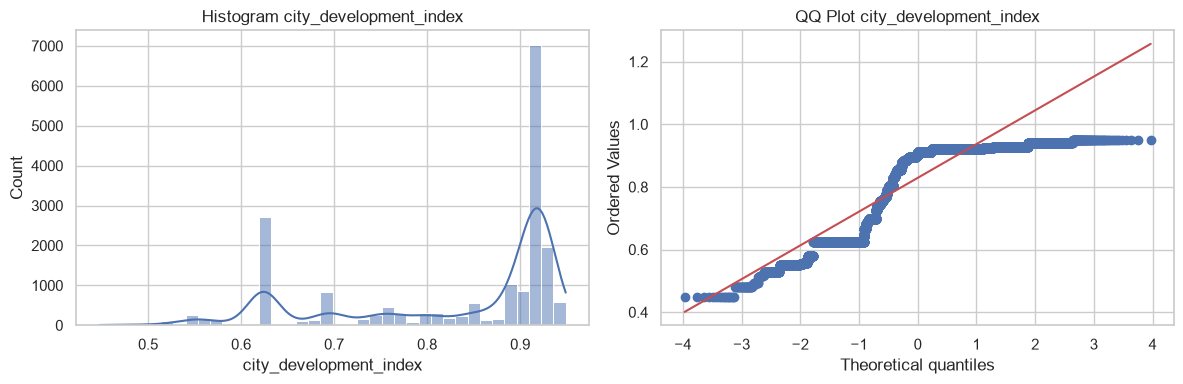

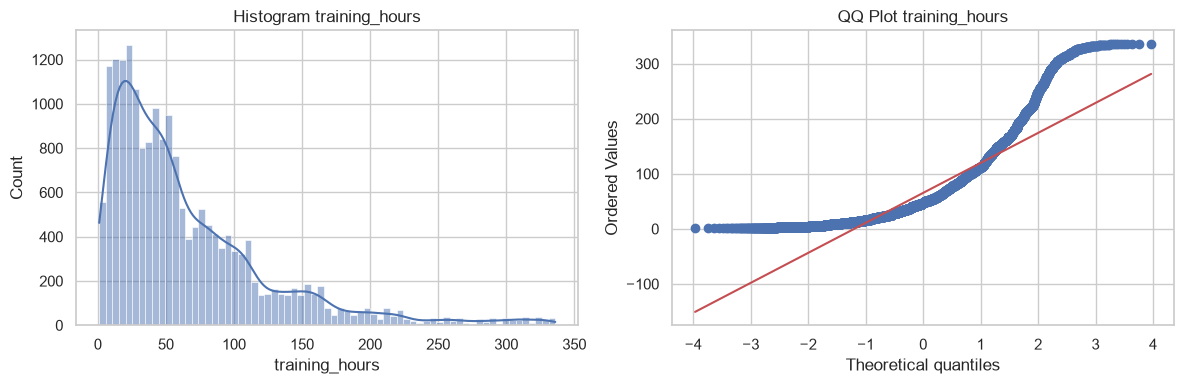

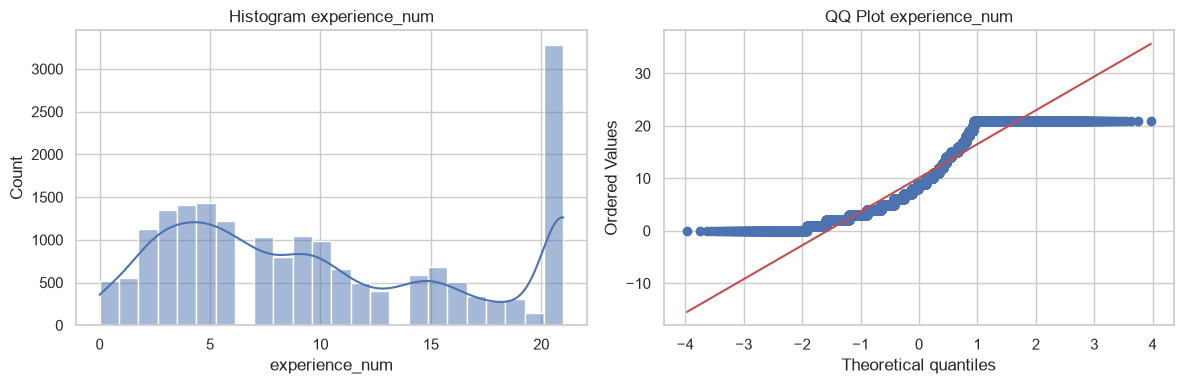

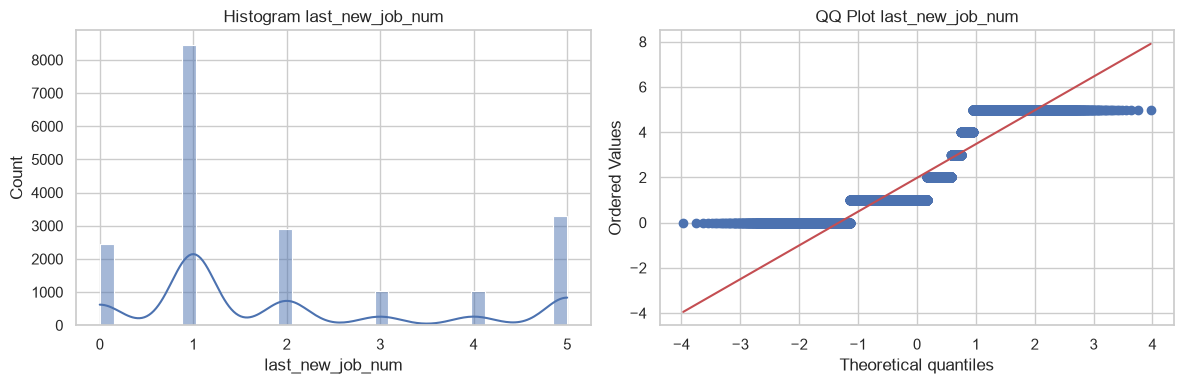

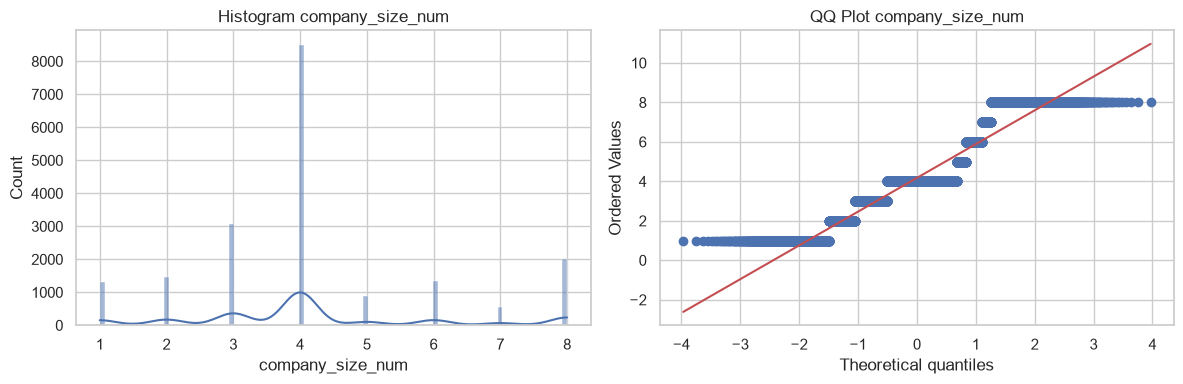

In [ ]:
# Histogram dan QQ plot
for col in norm_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram {col}")

    stats.probplot(df[col].dropna(), dist="norm", plot=ax[1])
    ax[1].set_title(f"QQ Plot {col}")

    plt.tight_layout()
    plt.show()

## Feature Engineering

In [ ]:
# Segmentasi untuk analisis dashboard
df["experience_group"] = pd.cut(
    df["experience_num"],
    bins=[-1, 1, 5, 10, 21],
    labels=["Entry", "Junior", "Mid", "Senior"]
)

df["city_group"] = pd.cut(
    df["city_development_index"],
    bins=[0, 0.60, 0.75, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

df["training_group"] = pd.cut(
    df["training_hours"],
    bins=[-1, 25, 50, 100, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

df["job_change_flag"] = np.where(df["target"] == 1, "Yes", "No")

In [ ]:
# Ubah kolom kategorikal menjadi category type agar lebih rapi
category_cols = [
    "city", "gender", "relevant_experience", "enrolled_university",
    "education_level", "major_discipline", "company_size", "company_type",
    "target_label", "experience_group", "city_group", "training_group", "job_change_flag"
]

for col in category_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Shape final:", df.shape)
display(df.head())

Shape final: (19158, 22)


,enrollee_id,city,city_development_index,gender,relevant_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,target_label,experience_num,last_new_job_num,company_size_num,experience_group,city_group,training_group,job_change_flag
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1,Job Change,21,1,4,Senior,High,Medium,Yes
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0,Stay,15,5,3,Senior,High,Medium,No
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0,Stay,5,0,4,Junior,Medium,High,No
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1,Job Change,0,0,4,Entry,High,High,Yes
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0,Stay,21,4,3,Senior,High,Low,No


# Exploratory Data Analysis

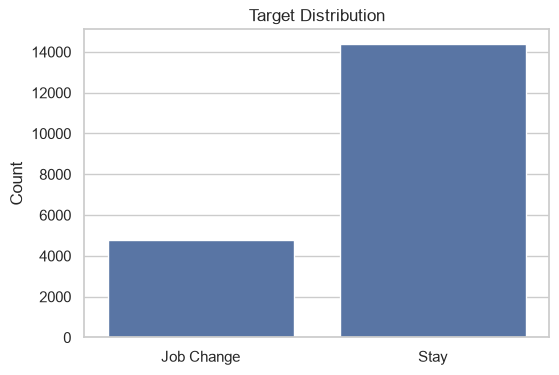

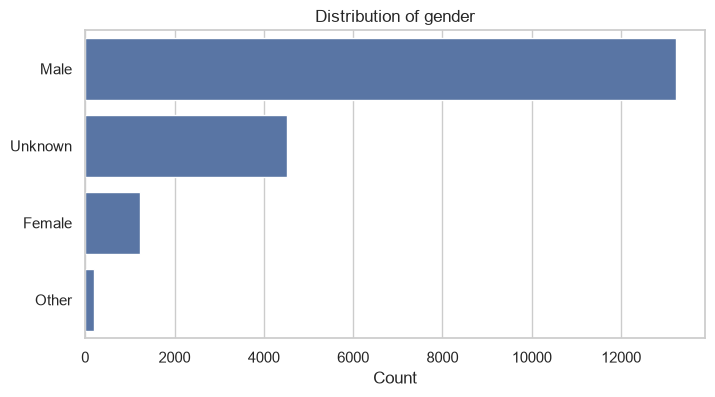

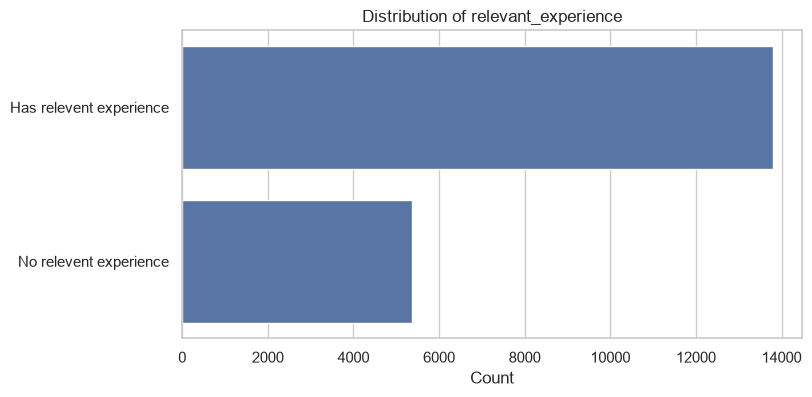

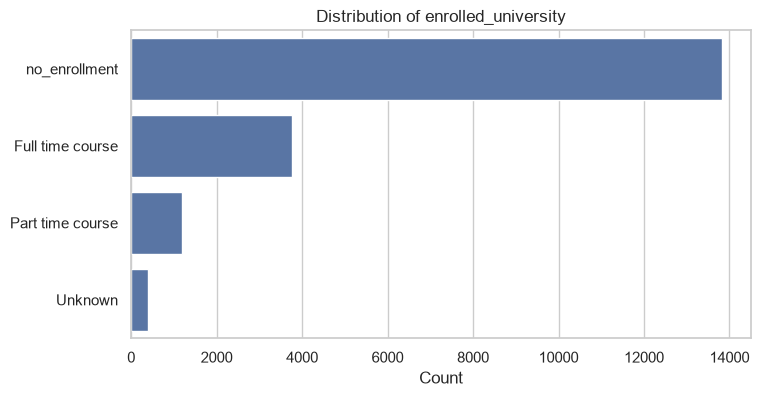

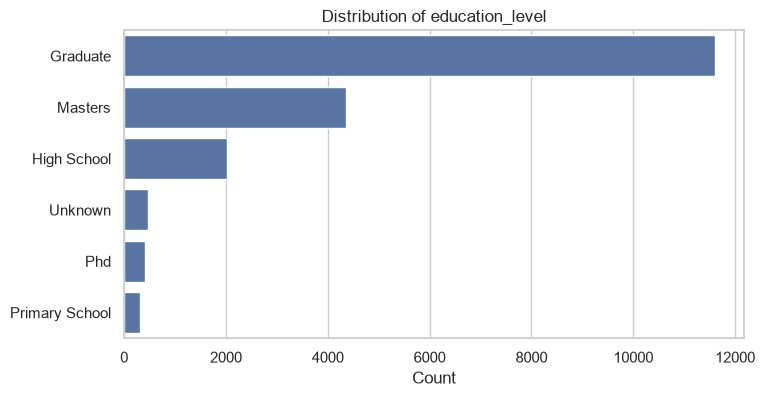

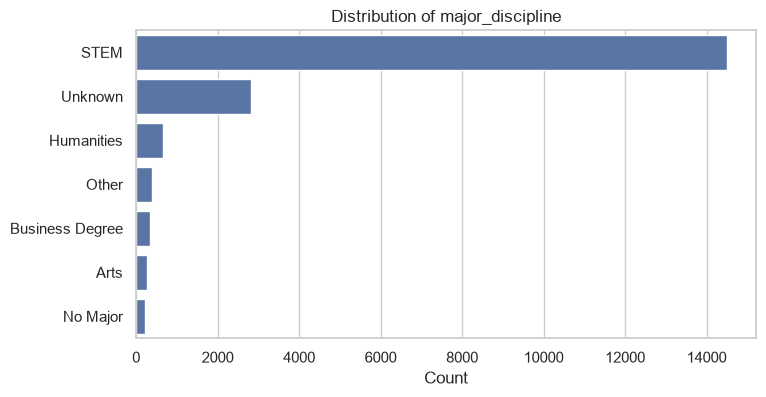

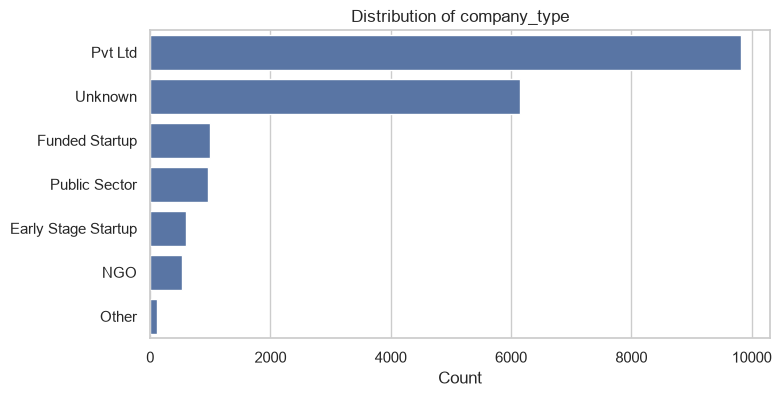

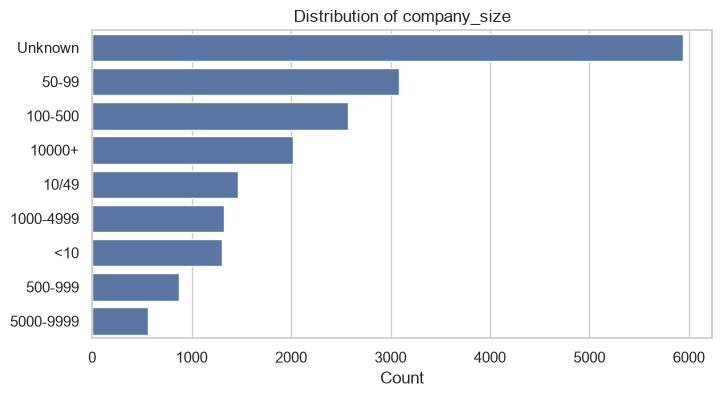

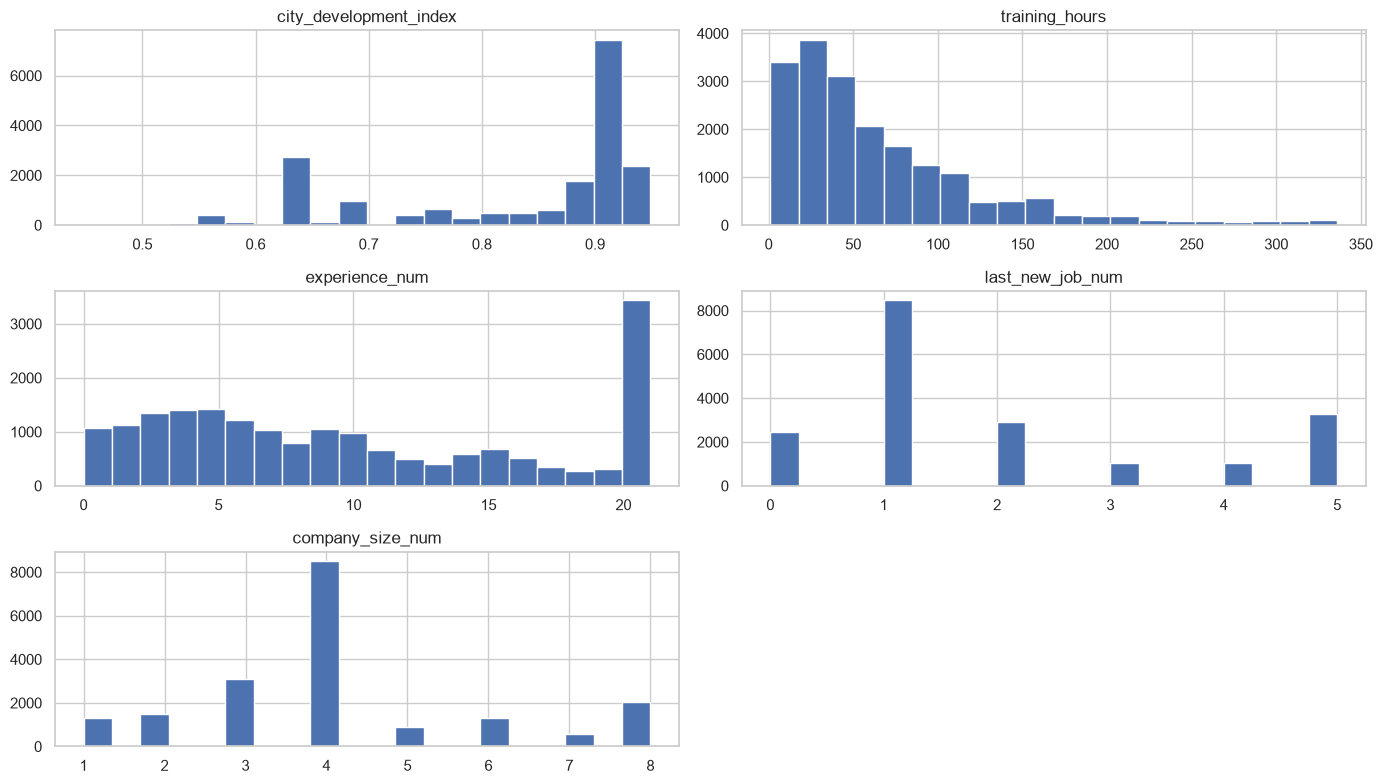

In [ ]:
# Univariate

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target_label")
plt.title("Target Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

cat_cols = [
    "gender", "relevant_experience", "enrolled_university",
    "education_level", "major_discipline", "company_type", "company_size"
]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts(dropna=False).index
    sns.countplot(data=df, y=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.show()

num_cols = ["city_development_index", "training_hours", "experience_num", "last_new_job_num", "company_size_num"]

df[num_cols].hist(figsize=(14,8), bins=20)
plt.tight_layout()
plt.show()

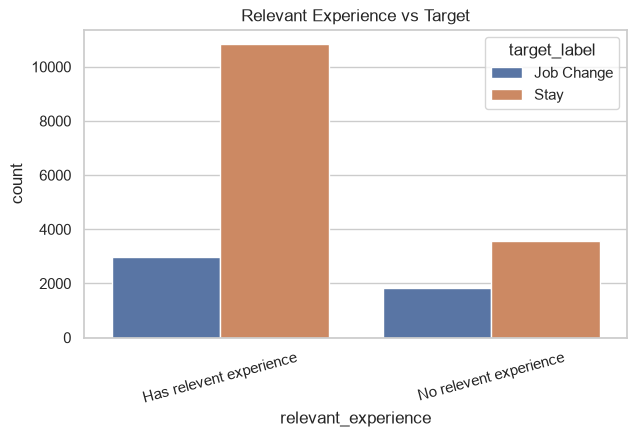

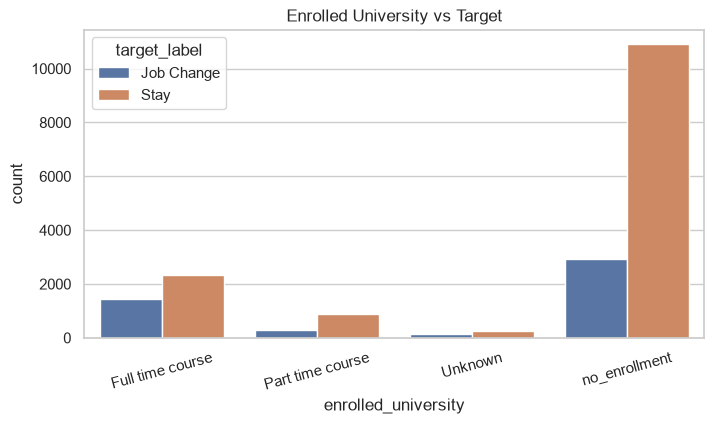

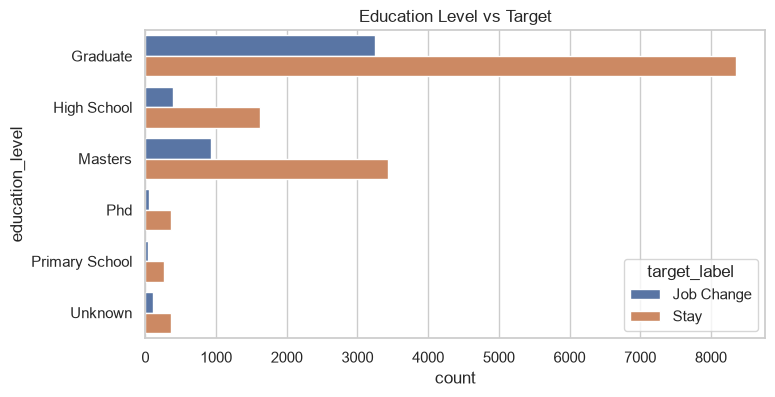

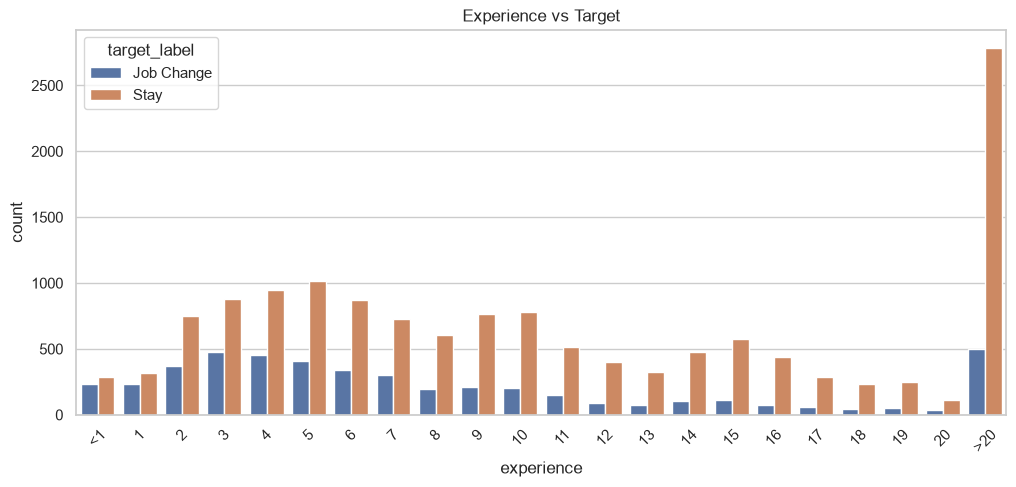

In [ ]:
# Target Analysis

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="relevant_experience", hue="target_label")
plt.title("Relevant Experience vs Target")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="enrolled_university", hue="target_label")
plt.title("Enrolled University vs Target")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, y="education_level", hue="target_label")
plt.title("Education Level vs Target")
plt.show()

exp_order = ["<1"] + [str(i) for i in range(1, 21)] + [">20"]

plt.figure(figsize=(12,5))
sns.countplot(data=df, x="experience", hue="target_label", order=exp_order)
plt.title("Experience vs Target")
plt.xticks(rotation=45)
plt.show()

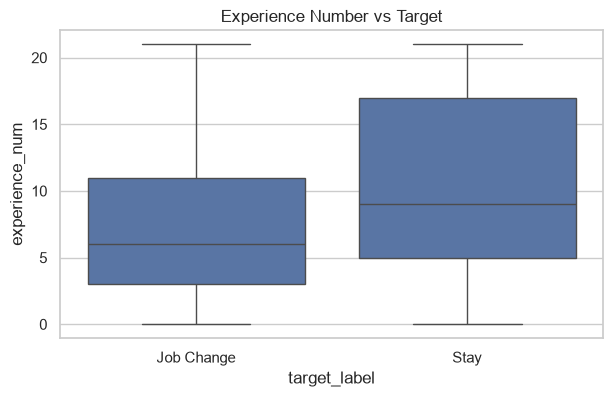

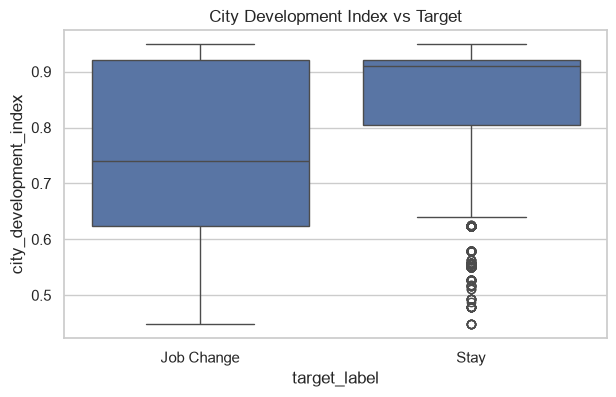

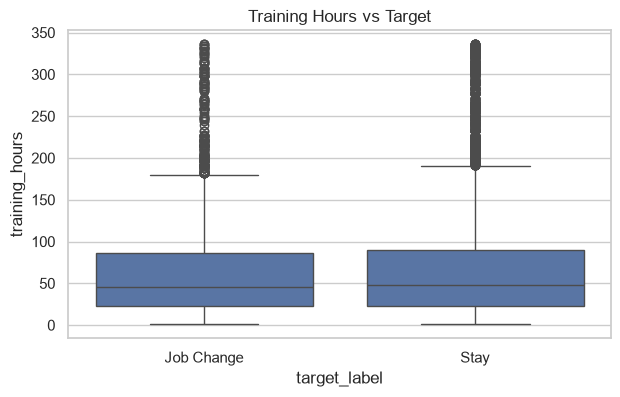

In [ ]:
# Bivariate
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="target_label", y="experience_num")
plt.title("Experience Number vs Target")
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="target_label", y="city_development_index")
plt.title("City Development Index vs Target")
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="target_label", y="training_hours")
plt.title("Training Hours vs Target")
plt.show()

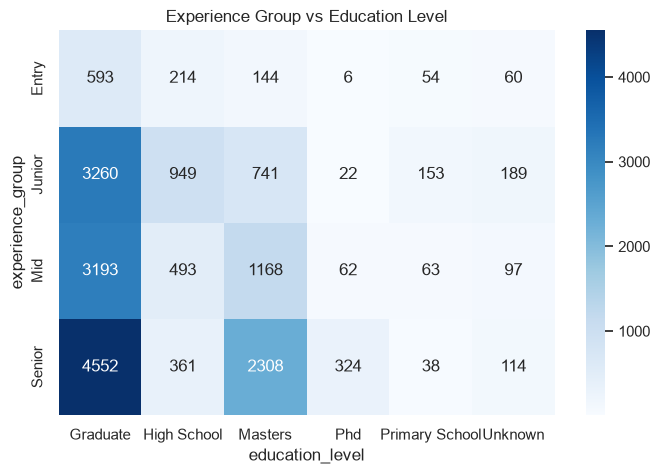

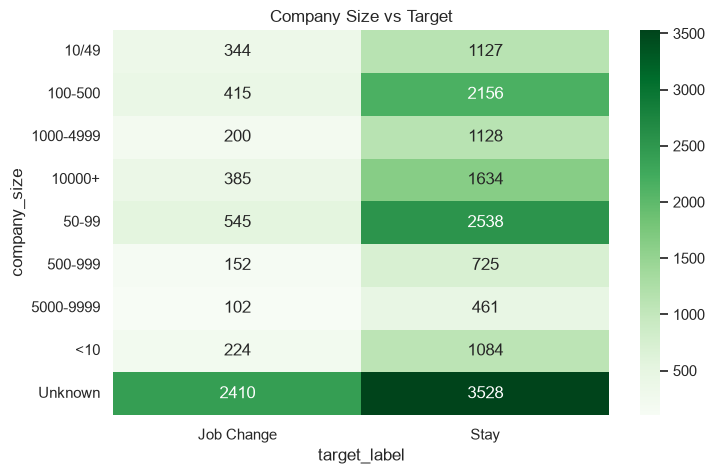

In [ ]:
# Multivariate
df["experience_group"] = pd.cut(
    df["experience_num"],
    bins=[-1, 1, 5, 10, 21],
    labels=["Entry", "Junior", "Mid", "Senior"]
)

pivot = pd.crosstab(df["experience_group"], df["education_level"])

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="g", cmap="Blues")
plt.title("Experience Group vs Education Level")
plt.show()
pivot = pd.crosstab(df["company_size"], df["target_label"])

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="g", cmap="Greens")
plt.title("Company Size vs Target")
plt.show()

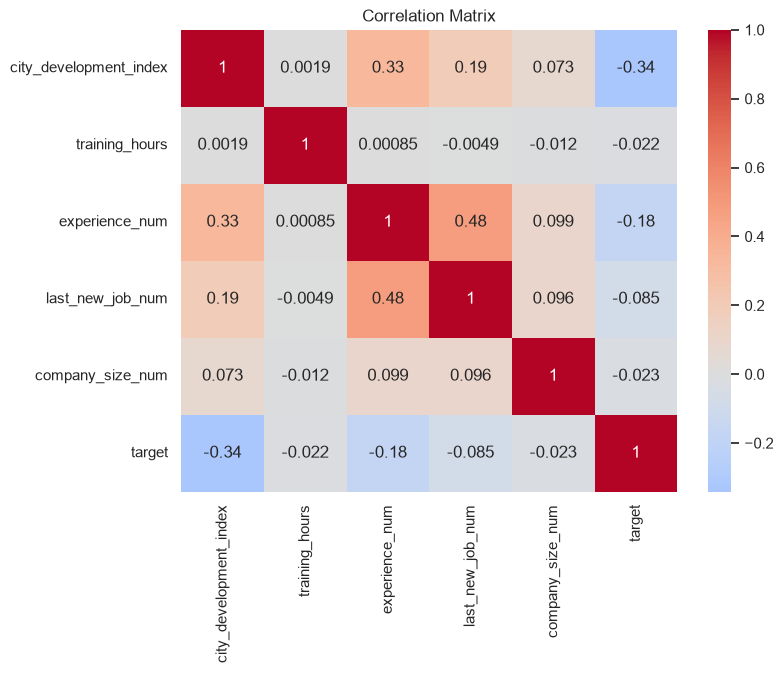

In [ ]:
# Correlation Analysis
corr = df[[
    "city_development_index",
    "training_hours",
    "experience_num",
    "last_new_job_num",
    "company_size_num",
    "target"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

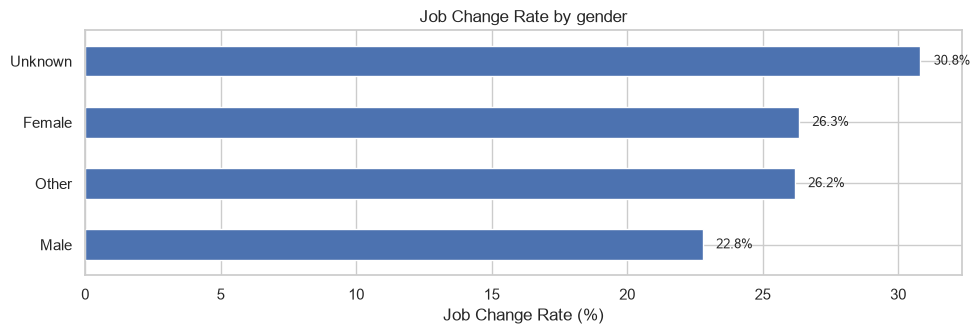

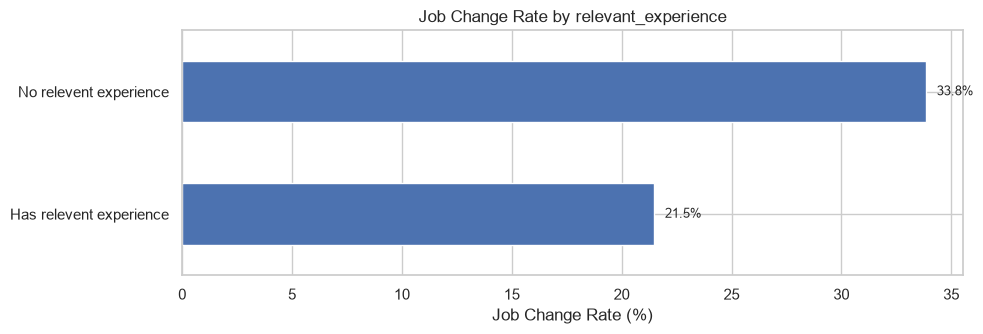

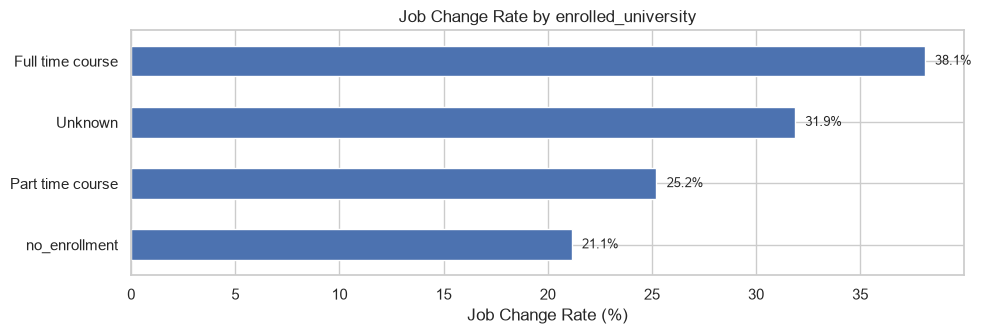

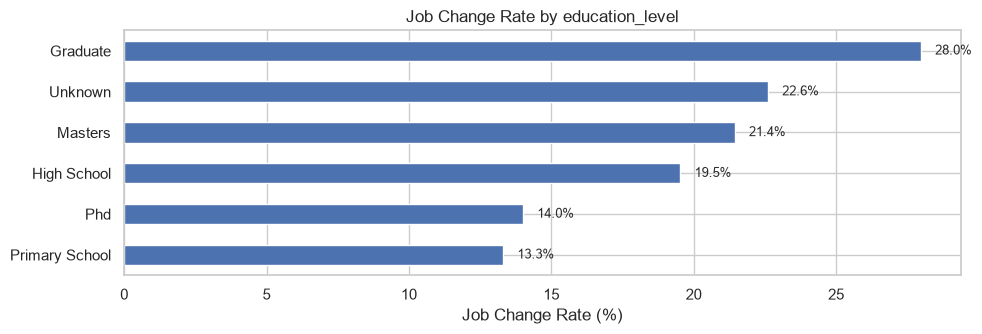

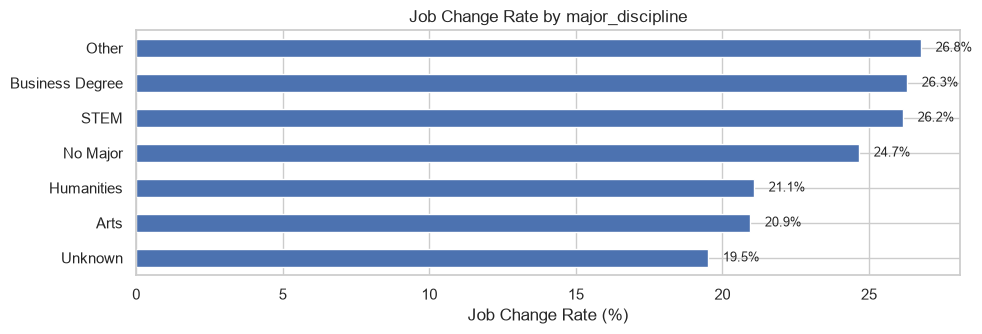

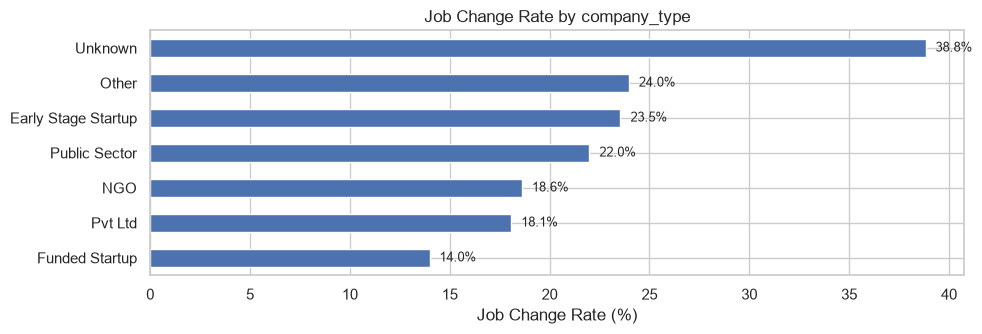

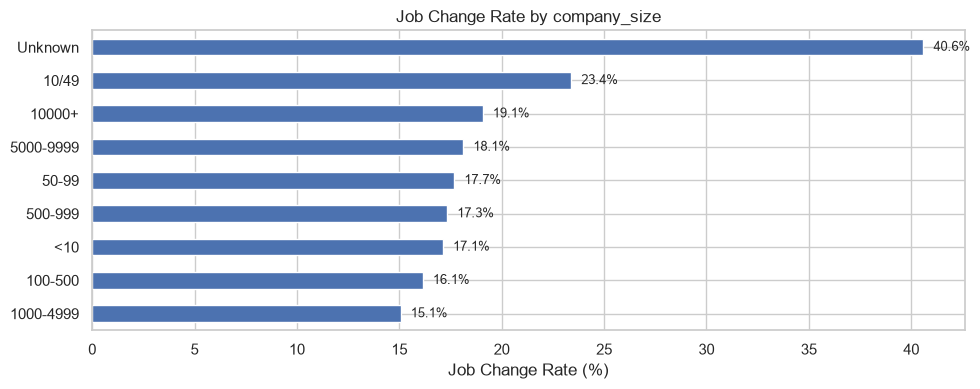

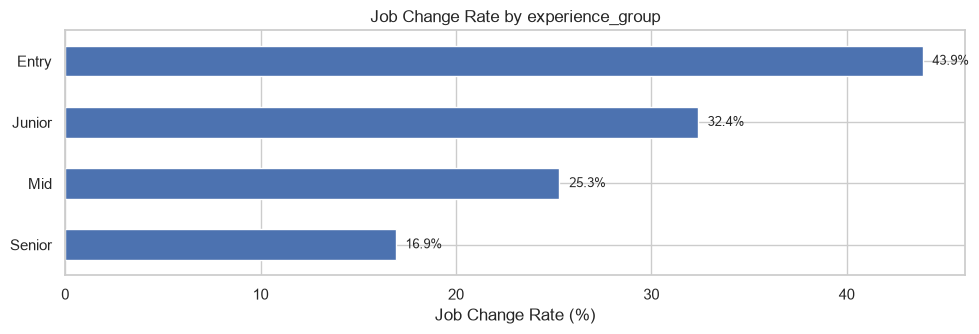

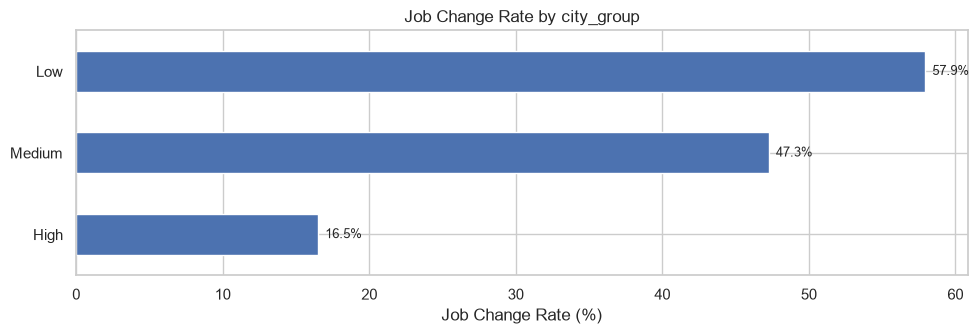

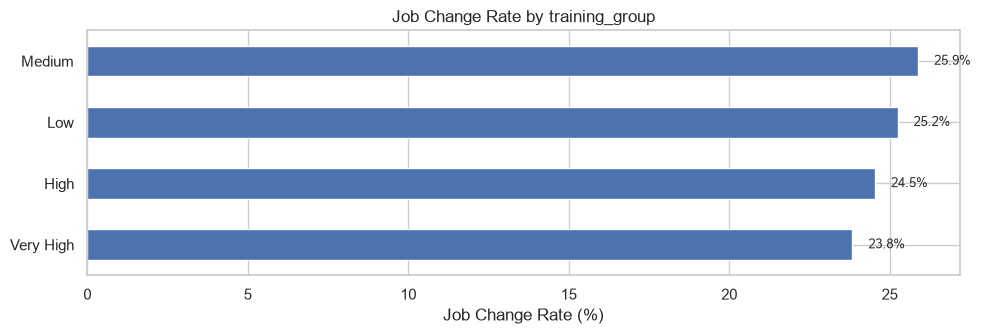

In [ ]:
# Job Change Rate Analysis
# Menampilkan persentase kandidat yang job change pada setiap segmen

def plot_job_change_rate(data, col, order=None, title=None):
    rate = data.groupby(col)["target"].mean().mul(100)
    if order is not None:
        rate = rate.reindex(order)
    rate = rate.dropna().sort_values(ascending=True)

    plt.figure(figsize=(10, max(3.5, 0.45 * len(rate))))
    ax = rate.plot(kind="barh")
    ax.set_xlabel("Job Change Rate (%)")
    ax.set_ylabel("")
    ax.set_title(title or f"Job Change Rate by {col}")

    for i, v in enumerate(rate.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

rate_cols = [
    "gender",
    "relevant_experience",
    "enrolled_university",
    "education_level",
    "major_discipline",
    "company_type",
    "company_size",
    "experience_group",
    "city_group",
    "training_group"
]

for col in rate_cols:
    if col in df.columns:
        plot_job_change_rate(df, col, title=f"Job Change Rate by {col}")


In [ ]:
# Crosstab Percentage Analysis
# Menampilkan proporsi Stay vs Job Change dalam persen untuk tiap kategori

def show_crosstab_pct(data, row_col, col="target_label"):
    table = pd.crosstab(data[row_col], data[col], normalize="index") * 100
    display(table.round(2))

crosstab_cols = [
    "gender",
    "relevant_experience",
    "enrolled_university",
    "education_level",
    "major_discipline",
    "company_type",
    "company_size",
    "experience_group",
    "city_group",
    "training_group"
]

for col in crosstab_cols:
    if col in df.columns:
        print(f"=== {col} vs target_label (%) ===")
        show_crosstab_pct(df, col)
        print()


=== gender vs target_label (%) ===


target_label,Job Change,Stay
gender,,
Female,26.33,73.67
Male,22.78,77.22
Other,26.18,73.82
Unknown,30.81,69.19



=== relevant_experience vs target_label (%) ===


target_label,Job Change,Stay
relevant_experience,,
Has relevent experience,21.47,78.53
No relevent experience,33.84,66.16



=== enrolled_university vs target_label (%) ===


...

target_label,Job Change,Stay
experience_group,,
Entry,43.88,56.12
Junior,32.39,67.61
Mid,25.30,74.70
Senior,16.92,83.08



=== city_group vs target_label (%) ===


target_label,Job Change,Stay
city_group,,
Low,57.93,42.07
Medium,47.25,52.75
High,16.50,83.50



=== training_group vs target_label (%) ===


target_label,Job Change,Stay
training_group,,
Low,25.25,74.75
Medium,25.89,74.11
High,24.54,75.46
Very High,23.84,76.16


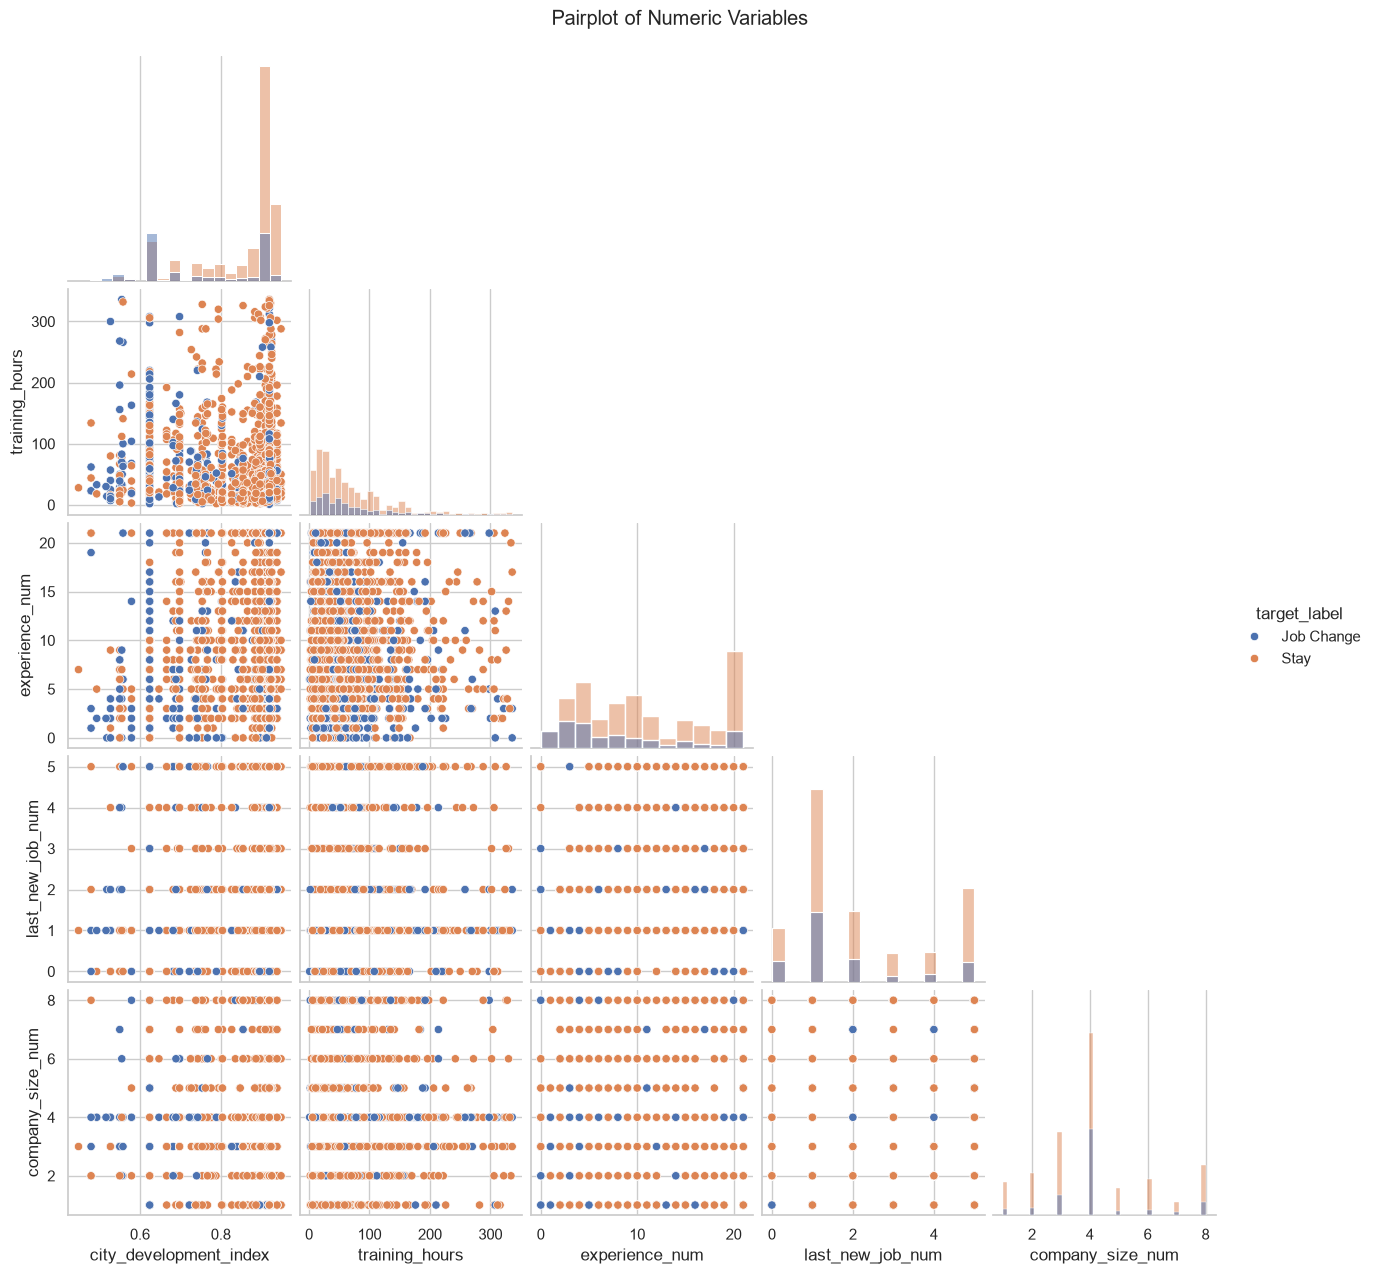

In [ ]:
# Additional Multivariate / Correlation View
# Pairplot memakai sample agar proses tetap ringan

pair_cols = [
    "city_development_index",
    "training_hours",
    "experience_num",
    "last_new_job_num",
    "company_size_num"
]

pairplot_df = df[pair_cols + ["target_label"]].dropna().sample(
    n=min(2000, len(df)),
    random_state=42
)

sns.pairplot(
    pairplot_df,
    hue="target_label",
    diag_kind="hist",
    corner=True
)
plt.suptitle("Pairplot of Numeric Variables", y=1.02)
plt.show()


## Hypothesis Testing


In [ ]:
# Hypothesis Testing
from scipy import stats

def chi_square_with_cramers_v(data, col, target_col='target_label'):
    table = pd.crosstab(data[col], data[target_col])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    cramers_v = np.sqrt((chi2 / n) / max(1, min(r - 1, k - 1)))
    return {
        'Variable': col,
        'Test': 'Chi-Square',
        'Chi2': chi2,
        'p-value': p,
        'Cramers V': cramers_v,
        'Decision': 'Reject H0' if p < 0.05 else 'Fail to Reject H0'
    }

chi_vars = [
    'relevant_experience',
    'experience_group',
    'enrolled_university',
    'company_type',
    'education_level'
]

chi_results = []
for col in chi_vars:
    if col in df.columns:
        chi_results.append(chi_square_with_cramers_v(df.dropna(subset=[col, 'target_label']), col))

chi_results_df = pd.DataFrame(chi_results)
display(chi_results_df.sort_values('p-value'))

# Mann-Whitney U Test untuk Training Hours
stay = df.loc[df['target'] == 0, 'training_hours'].dropna()
job_change = df.loc[df['target'] == 1, 'training_hours'].dropna()

u_stat, p_val = stats.mannwhitneyu(stay, job_change, alternative='two-sided')

mw_result = pd.DataFrame({
    'Variable': ['training_hours'],
    'Test': ['Mann-Whitney U'],
    'Statistic': [u_stat],
    'p-value': [p_val],
    'Median Stay': [stay.median()],
    'Median Job Change': [job_change.median()],
    'Decision': ['Reject H0' if p_val < 0.05 else 'Fail to Reject H0']
})

display(mw_result)


,Variable,Test,Chi2,p-value,Cramers V,Decision
3,company_type,Chi-Square,959.829960,4.351920e-204,0.223832,Reject H0
1,experience_group,Chi-Square,627.892927,9.043907e-136,0.181037,Reject H0
2,enrolled_university,Chi-Square,463.533718,3.809312e-100,0.155548,Reject H0
0,relevant_experience,Chi-Square,315.338577,1.500663e-70,0.128296,Reject H0
4,education_level,Chi-Square,167.271406,2.787357e-34,0.093441,Reject H0


,Variable,Test,Statistic,p-value,Median Stay,Median Job Change,Decision
0,training_hours,Mann-Whitney U,34996517.0,0.05056,48.0,46.0,Fail to Reject H0


In [ ]:
# Ringkasan interpretasi otomatis
print('=== Interpretation Summary ===')
for _, row in chi_results_df.sort_values('p-value').iterrows():
    print(f"{row['Variable']}: p-value = {row['p-value']:.6f} | Cramer's V = {row['Cramers V']:.3f} | {row['Decision']}")

print()
print(f"training_hours: p-value = {p_val:.6f} | Median Stay = {stay.median():.2f} | Median Job Change = {job_change.median():.2f} | {'Reject H0' if p_val < 0.05 else 'Fail to Reject H0'}")


=== Interpretation Summary ===
company_type: p-value = 0.000000 | Cramer's V = 0.224 | Reject H0
experience_group: p-value = 0.000000 | Cramer's V = 0.181 | Reject H0
enrolled_university: p-value = 0.000000 | Cramer's V = 0.156 | Reject H0
relevant_experience: p-value = 0.000000 | Cramer's V = 0.128 | Reject H0
education_level: p-value = 0.000000 | Cramer's V = 0.093 | Reject H0

training_hours: p-value = 0.050560 | Median Stay = 48.00 | Median Job Change = 46.00 | Fail to Reject H0


## Save Clean Dataset

In [ ]:
# output_path = r"C:\Users\MSI1\Downloads\People Analytic\People Analytic - Data train_cleaned.csv"
# df.to_csv(output_path, index=False)
# print(f"Dataset bersih berhasil disimpan ke: {output_path}")